# **03 — Demand Forecast Model**
## **Ma3 | XGBoost Hourly Ridership Predictor**

Predicts how many passengers will need a matatu on a given route
during a given hour — so SACCOs can redeploy vehicles before the
peak hits, not after.

**Why XGBoost?**
Tabular data with clear categorical patterns (peak hours, weekends,
holidays) — XGBoost handles this better than deep learning here.
Same architecture that powered FraudShield V3.

**Features:**
- `hour`, `day_of_week`, `is_peak`, `is_weekend`, `is_holiday`, `route`

**Target:**
- `pax_demand` — total passengers expected that hour on that route

**Output:**
- `models/demand_model.joblib`
- `models/demand_scaler.joblib`

In [1]:
import numpy as np
import pandas as pd
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

DATA_DIR  = "../data"
MODEL_DIR = "../models"

print(f"XGBoost: {xgb.__version__} ✓")

XGBoost: 3.2.0 ✓


## **Step 1 — Load & Explore**

In [2]:
df = pd.read_csv(f"{DATA_DIR}/demand_dataset.csv")
print(f"Shape: {df.shape}")
print(df.dtypes)
print("\nTarget distribution:")
print(df["pax_demand"].describe().round(2))

Shape: (4860, 7)
route          object
hour            int64
day_of_week     int64
is_peak         int64
is_weekend      int64
is_holiday      int64
pax_demand      int64
dtype: object

Target distribution:
count    4860.00
mean       45.02
std        24.95
min         5.00
25%        26.00
50%        35.00
75%        75.00
max        97.00
Name: pax_demand, dtype: float64


## **Step 2 — Explore Demand Patterns**

Before training, let's confirm our synthetic data reflects
real Nairobi matatu patterns — peaks at commute hours,
lower demand on weekends and holidays.

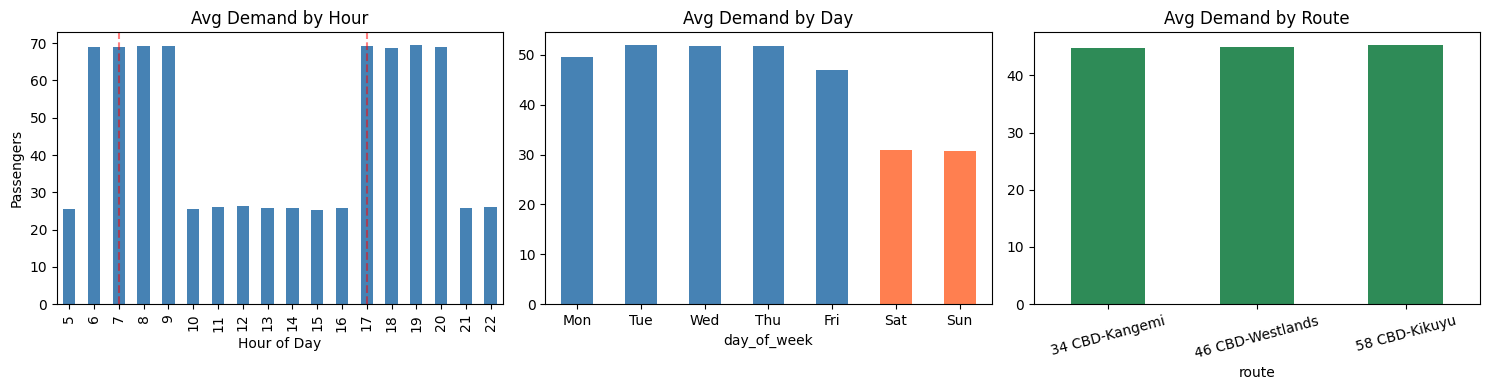

Patterns look realistic ✓


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Hourly average demand
df.groupby("hour")["pax_demand"].mean().plot(
    ax=axes[0], kind="bar", color="steelblue"
)
axes[0].set_title("Avg Demand by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Passengers")
axes[0].axvline(x=2, color="red", linestyle="--", alpha=0.5, label="6AM")
axes[0].axvline(x=12, color="red", linestyle="--", alpha=0.5, label="5PM")

# Demand by day of week
df.groupby("day_of_week")["pax_demand"].mean().plot(
    ax=axes[1], kind="bar",
    color=["steelblue"]*5 + ["coral"]*2
)
axes[1].set_title("Avg Demand by Day")
axes[1].set_xticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], rotation=0)

# Demand by route
df.groupby("route")["pax_demand"].mean().plot(
    ax=axes[2], kind="bar", color="seagreen"
)
axes[2].set_title("Avg Demand by Route")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/demand_patterns.png", dpi=100)
plt.show()
print("Patterns look realistic ✓")

## **Step 3 — Feature Engineering**

Encode route as integer — XGBoost handles label-encoded
categoricals well without needing one-hot expansion.
We also add a `hour_sin` / `hour_cos` cyclical encoding
so the model knows hour 23 is close to hour 0.

In [4]:
le = LabelEncoder()
df["route_encoded"] = le.fit_transform(df["route"])
joblib.dump(le, f"{MODEL_DIR}/demand_label_encoder.joblib")

# Cyclical hour encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

FEATURES = [
    "hour", "hour_sin", "hour_cos",
    "day_of_week", "is_peak",
    "is_weekend", "is_holiday",
    "route_encoded"
]
TARGET = "pax_demand"

X = df[FEATURES].values
y = df[TARGET].values

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"X: {X.shape}  y: {y.shape}")

Features (8): ['hour', 'hour_sin', 'hour_cos', 'day_of_week', 'is_peak', 'is_weekend', 'is_holiday', 'route_encoded']
X: (4860, 8)  y: (4860,)


## **Step 4 — Train / Test Split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (3888, 8)  Test: (972, 8)


## **Step 5 — Train XGBoost**

We use early stopping on a validation set inside XGBoost itself.
`n_estimators=500` is the ceiling — early stopping will halt before that.

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric="mae",
    verbosity=1
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-mae:20.63595
[50]	validation_0-mae:4.51129
[100]	validation_0-mae:4.23091
[108]	validation_0-mae:4.23413

Best iteration: 88


## **Step 6 — Evaluate**

In [7]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} passengers")
print(f"RMSE: {rmse:.2f} passengers")
print(f"R²:   {r2:.4f}")

# Cross-validation on full dataset
cv_scores = cross_val_score(
    xgb.XGBRegressor(
        n_estimators=model.best_iteration,
        learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    ),
    X, y, cv=5, scoring="neg_mean_absolute_error"
)
print(f"\n5-Fold CV MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")

MAE:  4.23 passengers
RMSE: 5.27 passengers
R²:   0.9564

5-Fold CV MAE: 4.06 ± 0.10


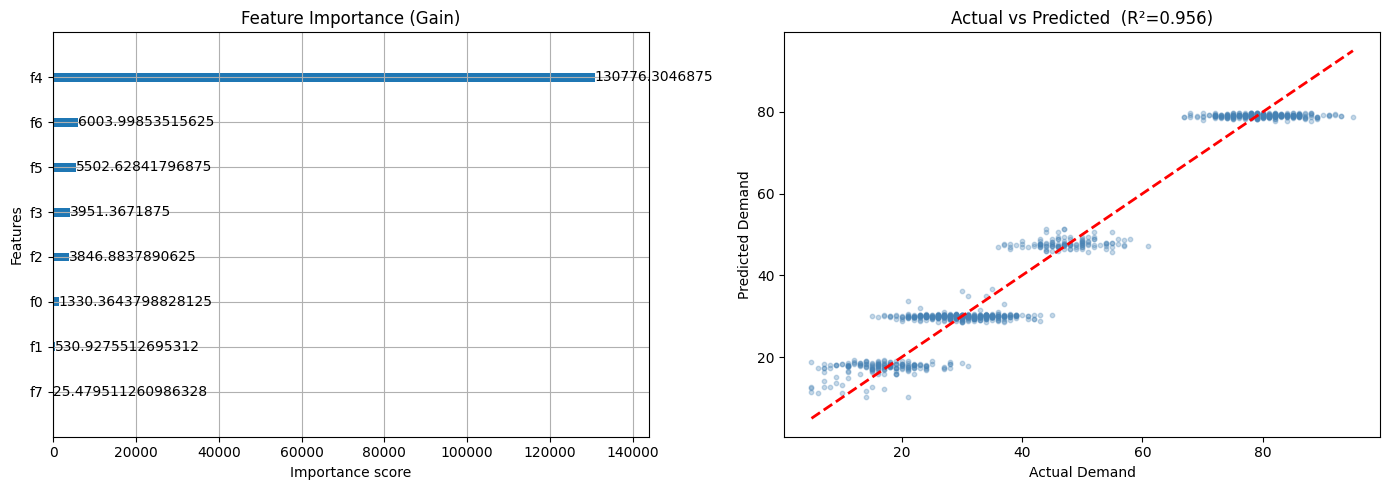

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
xgb.plot_importance(model, ax=axes[0], max_num_features=8, importance_type="gain")
axes[0].set_title("Feature Importance (Gain)")

# Actual vs Predicted
axes[1].scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], "r--", lw=2)
axes[1].set_xlabel("Actual Demand")
axes[1].set_ylabel("Predicted Demand")
axes[1].set_title(f"Actual vs Predicted  (R²={r2:.3f})")

plt.tight_layout()
plt.savefig(f"{MODEL_DIR}/demand_evaluation.png", dpi=100)
plt.show()

## **Step 7 — Sanity Check**

Simulate what a SACCO manager would see on the dashboard:
predicted demand for the next 3 hour slots per route.

In [9]:
def predict_demand(route_name, hour, day_of_week, is_holiday=0):
    route_enc = le.transform([route_name])[0]
    hour_sin  = np.sin(2 * np.pi * hour / 24)
    hour_cos  = np.cos(2 * np.pi * hour / 24)
    peak      = 1 if (6 <= hour <= 9) or (17 <= hour <= 20) else 0
    weekend   = 1 if day_of_week >= 5 else 0
    features  = np.array([[hour, hour_sin, hour_cos,
                           day_of_week, peak, weekend,
                           is_holiday, route_enc]])
    pax = float(model.predict(features)[0])
    level = "🔴 HIGH" if pax > 60 else "🟡 MEDIUM" if pax > 30 else "🟢 LOW"
    return round(pax, 1), level

print("SACCO Dashboard — Demand Forecast (Monday)")
print("=" * 52)
print(f"{'Route':<22} {'Hour':>5} {'Demand':>8} {'Load':>10}")
print("-" * 52)
for route in ["46 CBD-Westlands", "34 CBD-Kangemi", "58 CBD-Kikuyu"]:
    for hour in [7, 12, 18]:
        pax, level = predict_demand(route, hour, 0)
        print(f"{route:<22} {hour:>5}h {pax:>7} {level:>12}")
print("=" * 52)

SACCO Dashboard — Demand Forecast (Monday)
Route                   Hour   Demand       Load
----------------------------------------------------
46 CBD-Westlands           7h    78.7       🔴 HIGH
46 CBD-Westlands          12h    30.6     🟡 MEDIUM
46 CBD-Westlands          18h    79.1       🔴 HIGH
34 CBD-Kangemi             7h    78.8       🔴 HIGH
34 CBD-Kangemi            12h    31.1     🟡 MEDIUM
34 CBD-Kangemi            18h    78.7       🔴 HIGH
58 CBD-Kikuyu              7h    78.6       🔴 HIGH
58 CBD-Kikuyu             12h    30.4     🟡 MEDIUM
58 CBD-Kikuyu             18h    79.1       🔴 HIGH


In [10]:
joblib.dump(model, f"{MODEL_DIR}/demand_model.joblib")

print("=" * 45)
print("Model saved → models/demand_model.joblib")
print(f"MAE:  {mae:.2f} pax  |  RMSE: {rmse:.2f} pax  |  R²: {r2:.4f}")
print(f"Best trees: {model.best_iteration}")
print("Ready for 04_driver_scoring.ipynb ✓")
print("=" * 45)

Model saved → models/demand_model.joblib
MAE:  4.23 pax  |  RMSE: 5.27 pax  |  R²: 0.9564
Best trees: 88
Ready for 04_driver_scoring.ipynb ✓
